# Research Methods <br>UHH - Knowledge Technology Research Group - WiSe 2025/2026
## Assignment #5 - Estimated Sample Distribution & Empirical Sampling

***
### Group: A
### Names of members: Niloufar Baba Ahmadi, Narges Baba Ahmadi, Alexandra Helen Hooser

***

### Instructions:

Please answer the questions below. Copy this notebook and enter your answers underneath each task description, inserting cells as needed. You may use a combination of [python 3](https://www.python.org), [markdown](http://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html), and [LaTex](https://towardsdatascience.com/write-markdown-latex-in-the-jupyter-notebook-10985edb91fd) to formulate your responses. In order to successfully complete the assignment, you will need the lecture material provided in the [RM moodle course](https://lernen.min.uni-hamburg.de/course/view.php?id=5728), especially L08 & L09.

**Make sure to use only a copy of this notebook for your answers instead of a new/blank notebook.**

### Grading Criteria:

In order to successfully pass this assignment, you will need **at least a total of 70 points out of 100 points**, and **every** task has to be tackled.

### Submission:

Please upload the following two files **until Tuesday, January 6, 2026, 20:00 CET (Germany)** together in a .zip archive in moodle:
1. a (single) copy of this jupyter notebook containing your answers for all tasks (file extension: .ipynb)
2. an [exported PDF document](https://jupyterlab.readthedocs.io/en/stable/user/export.html) of the jupyter notebook (file extension: .pdf)

### Presentation:

Make sure that each (!) group member takes part in solving this assignment and is prepared to answer questions and/or present solutions from your submitted notebook during our assignment revision meeting scheduled for **Wednesday, January 14, 2026, 10:00 - 13:00 CET (Germany)**.

### File Naming:

Add the group letter to the file name prior to submission. For example, if your group letter is "A" (see group selection in moodle), you would use the following filename:
1. RM_A05_Group_A.ipynb
2. RM_A05_Group_A.pdf

***
***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import nct
import matplotlib.pyplot as plt
from scipy.stats import t as tdist, norm

In [ ]:
path = "/content/drive/MyDrive/uhh/WiSo2025 26/RM seminar/A02 /data/CRU_data.csv"
cru = pd.read_csv(path)

#### Task 1 **[40 points] Hypothesis Testing**

In Assignment 2 (Task 4), you investigated monthly temperature changes over a 50-year period for Spain and Pakistan. One hypothesis was that Pakistan was more affected than Spain by climate change. For this task, you will need to compute the temperature difference for each month starting from January 1964 compared to that same month in 1914 (e.g., comparing January 1964 with January 1914, February 1964 with February 1914, and so on). As a result, you have two datasets (one for Spain and one for Pakistan) each representing the monthly change in temperature over a 50-year span.

**Research Question:** *Is the average long-term warming (as measured by the 50-year temperature differences) in Pakistan significantly greater than the average long-term warming in Spain?*

1. Clearly state the null ($H_0$) and alternative ($H_1$) hypotheses that correspond to the above research question.
2. a. Identify an appropriate statistical test to compare the mean temperature differences from the two samples (Pakistan vs. Spain) and justify why this test is suitable.<br>
   b. Specify the underlying assumptions of the test (e.g., data scale, normality, independence, sample size considerations).<br>
   c. State the parameters you used (e.g., significance level, one-tailed vs. two-tailed) and conduct the test.
3. Present your test results in a scientifically appropriate manner. Discuss whether there is a statistically significant difference between the two countries’ temperature changes. Consider potential limitations such as data quality, sample size, time-period selection, or other contextual factors.
4. Determine the statistical power and effect size for your chosen test. Explain what these values mean in the context of your analysis and discuss factors that may have influenced the power and the practical importance of the observed effect size.


#### Our Solution to Task 1

1. Let $μ_P$ be the mean 50-year monthly temperature increase in Pakistan and $μ_S$ be the mean 50-year monthly temperature increase in Spain. Then our null and alternative hypotheses are:

- $H_0$: $μ_P - μ_S ≤ 0$ (Pakistan's average 50-year warming is not greater than Spain's.)

- $H_1$: $μ_P - μ_S > 0$ (Pakistan's average 50-year warming is greater than Spain's.)

2. a. A two-sample t-test with pooled variance was used to compare the mean temperature differences between Spain and Pakistan. Because:

- - Population standard deviations are unknown.

- - The two samples (Spain and Pakistan) are independent as temperature differences are measured separately for each country so a two-sample t-test is chosen over a paired t-test.

- - The ratio of variances is ≈1.1 which is below the rule-of-thumb threshold of 2, making the equal-variance assumption reasonable (as discussed in L08) so we use pooled variance.



In [ ]:
months = ["JAN","FEB","MAR","APR","MAY","JUN","JUL","AUG","SEP","OCT","NOV","DEC"]
cols = [f"TMP_MEAN_{m}" for m in months]

avg_temps = cru.groupby(["COUNTRY","YEAR"], as_index=False)[cols].mean()

warm = avg_temps.query('COUNTRY in ["SPAIN","PAKISTAN"] and 1964 <= YEAR < 2014').copy()
base = avg_temps.query('COUNTRY in ["SPAIN","PAKISTAN"] and 1914 <= YEAR < 1964').copy()

base["YEAR"] = base["YEAR"] + 50
merged = warm.merge(base, on=["COUNTRY","YEAR"], suffixes=("", "_base"), how="inner")

for c in cols:
    merged[c] = merged[c] - merged[f"{c}_base"]

diff_df = merged[["COUNTRY","YEAR"] + cols].sort_values(["COUNTRY","YEAR"]).reset_index(drop=True)


In [ ]:
spain = diff_df.query('COUNTRY=="SPAIN"')[cols].to_numpy().ravel()
pak = diff_df.query('COUNTRY=="PAKISTAN"')[cols].to_numpy().ravel()

var_s = spain.var(ddof=1)
var_p = pak.var(ddof=1)
ratio = max(var_s, var_p) / min(var_s, var_p)

print(f"Variance Spain    = {var_s:.4f}")
print(f"Variance Pakistan = {var_p:.4f}")
print(f"Variance ratio    = {ratio:.3f}")


Variance Spain    = 2.0081
Variance Pakistan = 1.7945
Variance ratio    = 1.119


2. b. Our assumptions are:

- - The samples have equal sizes

- - The data are on the same interval scale (temperature differences in °C).

- - Monthly temperature differences for Spain and Pakistan are independent.

- - The sampling distribution of the mean is approximately normal

- - Sample variances are sufficiently similar to justify pooling

2. c. The parameters for the test are:

- - Significance level (α): 0.05
- - Directional test (one-tailed): Our alternative hypothesis specifies that warming in Pakistan is greater than in Spain.

In [ ]:
# parameters
alpha = 0.05
test_type = "one-tailed"

In [ ]:
# Two-sample t-test (pooled)
result = stats.ttest_ind(a=pak, b=spain, equal_var=True)

t_stat = result.statistic
p_two = result.pvalue

p_one = (p_two / 2) if (t_stat > 0) else (1 - p_two / 2)

# Degrees of freedom (pooled)
df = len(spain) + len(pak) - 2

print("Two-sample pooled t-test:")
print(f"\nt({df}) = {t_stat:.3f}")
print(f"One-tailed p-value = {p_one:.3f}")
# print(f"\nMean(Pak) - Mean(Spain) = {pak.mean() - spain.mean():.4f} °C")

Two-sample pooled t-test:

t(1198) = -3.279
One-tailed p-value = 0.999


3. The test produced the following results:
- **t-statistic**: -3.279  
- **p-value**: 0.999
- **Degrees of Freedom (df)**: 1198

A one-tailed pooled two-sample t-test was conducted to test whether Pakistan experienced greater long-term warming than Spain. The test yielded $t(1198)=-3.279$, with a one-tailed p-value of 0.999. The null hypothesis was therefore not rejected. The negative test statistic indicates that the observed difference was in the opposite direction, with Spain exhibiting greater average warming than Pakistan.

**Limitations**

- **Data quality**: Historical temperature records may contain measurement uncertainties due to changes in instrumentation or station coverage.

- **Time-period selection**: The analysis depends on the chosen 50-year lag and the specific comparison window (1964-2013 vs. 1914-1963). Different time spans could yield different results.

- **Climate heterogeneity**: National-level averages may mask substantial regional variation in climate change impacts within each country.

4. We can determine the **effect size** using Cohen's $d$, which is calculated as:

$$
 d = \frac{\bar X_1 - \bar X_2}{s_p}
$$

The pooled standard deviation $s_p$ is computed as:
$$
s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1 + n_2 - 2}}
$$

In [ ]:
n1, n2 = len(pak), len(spain)
df = n1 + n2 - 2
alpha = 0.05


s12 = np.var(pak, ddof=1)
s22 = np.var(spain, ddof=1)
print("sp_pak =", s12)
print("sp_spain =", s22)
sp = np.sqrt(((n1-1)*s12 + (n2-1)*s22) / df)
print("sp =", round(sp, 3))

# Cohen's d
mean_diff = np.mean(pak) - np.mean(spain)
print("Mean_pak", np.mean(pak))
print("Mean_spain", np.mean(spain))
d = mean_diff / sp
print("Cohen's d =", round(d, 3))

sp_pak = 1.7944518363939903
sp_spain = 2.008099916527546
sp = 1.379
Mean_pak 0.33349999999999996
Mean_spain 0.5945
Cohen's d = -0.189


So we have:
$$
s_p = \sqrt{\frac{(599)1.7945 + (599)2.0081}{1198}}≈1.379
$$
$$
d=\frac{0.3335 - 0.5945}{1.379}≈-0.189
$$

$|d|\approx 0.189$ is a small effect. The sign is negative, meaning the average warming difference in Pakistan is lower than Spain in this dataset (opposite to the one-tailed hypothesis direction).

As for **statistical power** we calculated it below:

In [ ]:
# one-tailed power for H1: Pak > Spain
tcrit = stats.t.ppf(1 - alpha, df)
ncp = d / np.sqrt(1/n1 + 1/n2)
power_one = 1 - nct.cdf(tcrit, df, ncp)

# power if direction matched hypothesis (same magnitude)
power_one_dir = 1 - nct.cdf(tcrit, df, abs(ncp))

print("One-tailed power (H1 Pak>Spain, observed sign) =", power_one)
print("One-tailed power (if direction matched H1) =", round(power_one_dir, 3))

One-tailed power (H1 Pak>Spain, observed sign) = 4.2935127275711693e-07
One-tailed power (if direction matched H1) = 0.949


- The one-tailed power is ~0 because the observed effect goes opposite to the stated one-tailed hypothesis.
- The 0.949 shows the design has high sensitivity if the effect is in the hypothesized direction, largely due to the large n.

The observed standardized effect was (Cohen's ≈-0.189) a small effect.

- **Strong overlap:** A small $|d|$ implies the Pakistan and Spain distributions overlap heavily, so the difference is not “large” in a practical, day-to-day sense.

- **Small shift vs. variability:** With pooled SD ($s_p≈1.38$), the mean difference is roughly  
  $$
  \Delta = \bar X_{Pak}-\bar X_{Spain} \approx d\cdot s_p \approx (-0.189)(1.38)\approx -0.26^\circ C
  $$
  So Spain's average warming difference is only about **0.26°C higher**, while typical month-to-month variation is much larger (~1.38°C).

- **Statistical vs practical:** With a large nominal sample size, even small effects can become statistically detectable, but the **practical importance** remains modest because the effect is small.

#### Task 2 **[60 points] Experiment Simulation**
In this task we want to simulate the process of human study participants using a Likert scale, to see (A) how such a scale changes the original data, and (B) how your analysis of the resulting data may be affected by different parameters.
Over the task you are going to do three things:
* Assume that the "real" answers (that people could give if asked on a continuous scale) are continuous, normally distributed around expected means.
* Match the answers that you sample from that distribution to a Likert Scale (i.e., choosing the answers that most closely match the answer the human wanted to give).
* Do analyses on the resulting sampling distribution to see what is possible and what the Likert data can reveal about the underlying distribution.<br>

We will use a 5-Point standard Likert scale: [strongly disagree, disagree, neutral, agree, strongly agree] and these answers would be coded for easier handling with the numbers [-2, -1, 0, 1, 2], respectively.

1. What problems do you expect if you use a Likert scale like this?

Your job is now to simulate the process using Monte-Carlo.</br>
_Note: For the remainder of the task, we will use two groups (C)ontrol and (T)reatment. We will give population means as tuples (e.g., (-1,1)) to define the two distributions to draw from for the two groups. Through the simulation you want to test the following hypotheses:_ $H_0$: $\mu_A = \mu_B$, $H_1$: $\mu_A \neq \mu_B$

The aim of this exercise is to understand how Likert-Scales can be evaluated, how experiments with questionnaires can be analyzed, and what questions you have to ask if doing so. Write your code in a modular, reusable way to quickly explore different parameters/biases/methods. Think carefully about matching source and Likert scale correctly. And as always: Provide an interpretation for your diagrams and results!

2. a. How do the sampling distributions look like for $H_0$ and $H_1$ for means (-1,1)? Choose a meaningful standard deviation for both groups. Visualize and interpret. <br>
   b. Use the same tuple of means and the following additional tuples: (1,0), (1.5, 0.5), (-2,-1) and for each tuple use at least two different standard deviations (i.e., eight combinations in total). Plot frequencies of Likert scale values for all combinations. <br>
   _Hint: For this subtask it is okay to write one combined interpretation for all diagrams created._ <br>
   d. What would be your test statistic you are going to use for the hypothesis test and why? <br>
   e. How would you choose your sample size and sampling size? Why?
2. What is the power of a $t$-test (two-sample, independent) and the Mann-Whitney-U test for your eight combinations? Compute for all tuples of means and the standard deviations. Interpret your results.
3. How could you model common biases (at least two) and how would they affect the outcome and power? Use your expected tuples of means and the standard deviations. Compute, interpret, and visualize. <br>
    _Hint: In the lectures 06 and 07 some common biases for these kinds of scales were discussed, but you can also choose other common [response biases](https://en.wikipedia.org/wiki/Response_bias) that you find interesting._
4. For the tuple of means of (1.5, 0.5), how large would the sample have to be in order to get a power of 80% for α=5%? Use the two different standard deviations as used in subtask 2b.

#### Our Solution to Task 2

1. Problems with a 5-point Likert scale:

- - Quantization / rounding distortion: many distinct continuous opinions map to the same Likert option. e.g. we have: -2 = strongly disagree, -1 = disagree, 0 = neutral, 1 = agree, 2 = strongly agree. If someone answers 0.01 it is way different from someone that answers 0.49 yet they are in the same category.

- - boundary effect: values beyond the ends pile up at ±2.

- - Distances between categories aren't guaranteed to be equal. e.g. going from -2 to -1 might mean “I'm less angry but still disagree" whereas going from 0 to 1 might mean “I actually changed my mind and now agree”

- - Response biases: central tendency (avoiding extreme ends), extreme responding (only choosing extreme ends), etc.

2. a.

We simulated the sampling distribution of $\Delta=\bar{Y}_T-\bar{Y}_C$ with Monte-Carlo. we drew latent normal responses for Control and Treatment, mapped them to the 5-point Likert scale {-2, -1, 0, 1, 2} by rounding and clipping, then computed $\Delta$. we used n=15 per group and $\sigma_C=\sigma_T=1.2$ to make ceiling/floor effects visible.

Under $H_0$ with $(\mu_C,\mu_T)=(-1,-1)$, $\Delta$ is centered near 0 ($mean \approx 0.002, sd \approx 0.373$) as expected when both groups come from the same population. Under $H_1$ with $(\mu_C,\mu_T)=(-1,1)$, the distribution shifts right ($mean \approx 1.751, sd \approx 0.377$). The center is below the latent difference of 2 because Likert responses are bounded at $\pm2$ so clipping compresses extremes and attenuates the observed effect.



In [ ]:
# Likert mapping
def to_likert(x):
    return np.clip(np.rint(x), -2, 2).astype(int)

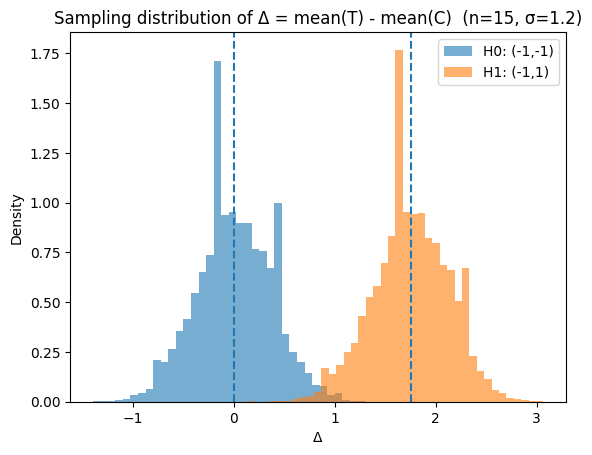

H0 mean, sd: 0.002129999999999999 0.37295095886843627
H1 mean, sd: 1.7509 0.37680153938262395


In [ ]:
# Parameters
n = 15
K = 20000
sigma_c = 1.2
sigma_t = 1.2

def simulate_mean_diff(mu_c, mu_t, sigma_c, sigma_t, n, K, seed=0):
    rng = np.random.default_rng(seed)
    diffs = np.empty(K)
    for k in range(K):
        c = to_likert(rng.normal(mu_c, sigma_c, size=n))
        t = to_likert(rng.normal(mu_t, sigma_t, size=n))
        diffs[k] = t.mean() - c.mean()
    return diffs

# H0: equal means
diffs_H0 = simulate_mean_diff(mu_c=-1, mu_t=-1, sigma_c=sigma_c, sigma_t=sigma_t, n=n, K=K, seed=1)

# H1: means (-1, 1)
diffs_H1 = simulate_mean_diff(mu_c=-1, mu_t=1, sigma_c=sigma_c, sigma_t=sigma_t, n=n, K=K, seed=2)

# Plot
plt.figure()
plt.hist(diffs_H0, bins=40, density=True, alpha=0.6, label="H0: (-1,-1)")
plt.hist(diffs_H1, bins=40, density=True, alpha=0.6, label="H1: (-1,1)")
plt.axvline(diffs_H0.mean(), linestyle="--")
plt.axvline(diffs_H1.mean(), linestyle="--")
plt.title(f"Sampling distribution of Δ = mean(T) - mean(C)  (n={n}, σ={sigma_c})")
plt.xlabel("Δ")
plt.ylabel("Density")
plt.legend()
plt.show()

print("H0 mean, sd:", diffs_H0.mean(), diffs_H0.std(ddof=1))
print("H1 mean, sd:", diffs_H1.mean(), diffs_H1.std(ddof=1))


2. b. Across all eight plots, when the standard deviation is smaller $(\sigma=0.5)$, the answers stay close to the mean so most responses fall into only one or two nearby Likert options. This makes the control and treatment groups easier to tell apart because there is less overlap. When the standard deviation is larger $(\sigma=1.2)$, the answers are more spread out and the two groups overlap more, so the difference is harder to see. The plots also show clear floor/ceiling effects near the ends of the scale. e.g. for $(\mu_C,\mu_T)=(-2,-1)$ many control answers are stuck at -2, and for (1.5,0.5) many control answers are stuck at +2. Overall, rounding to 5 choices and cutting off values at $\pm2$ changes the shapes and can make group differences look smaller.


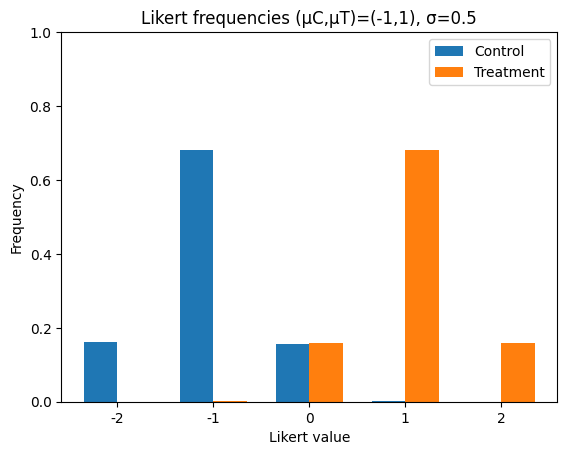

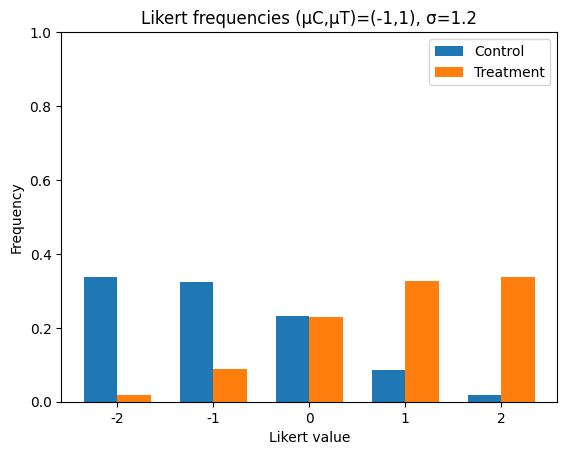

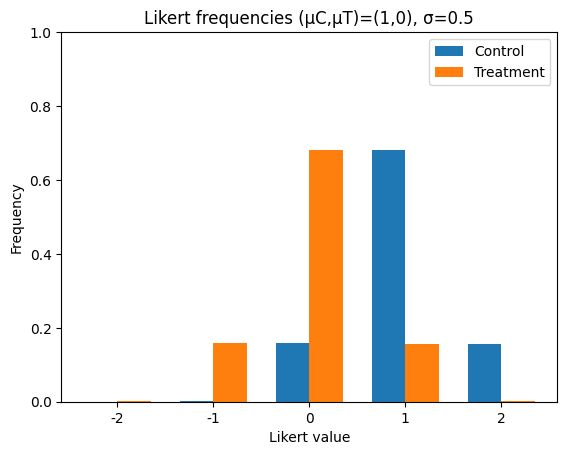

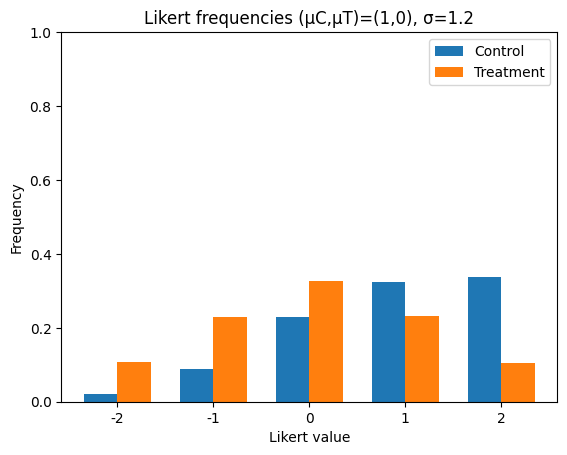

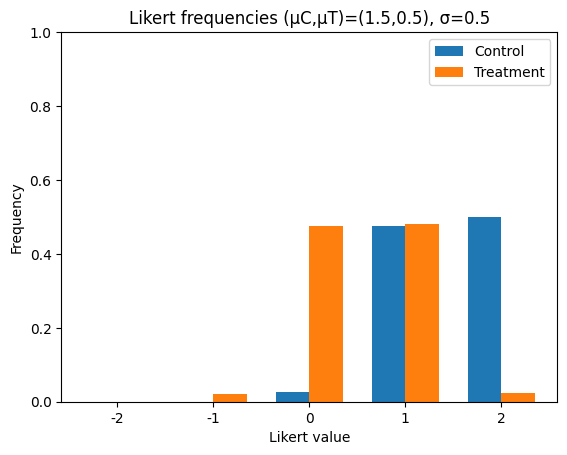

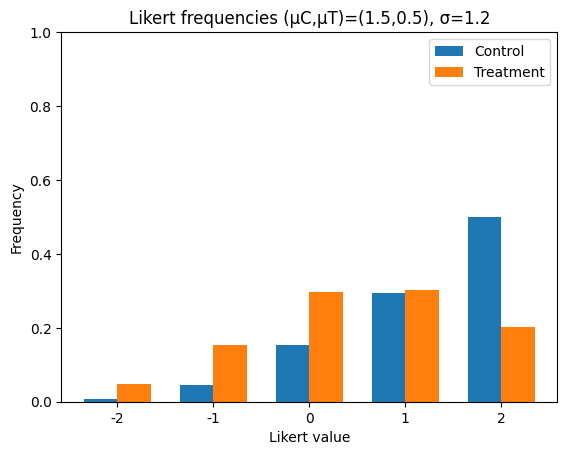

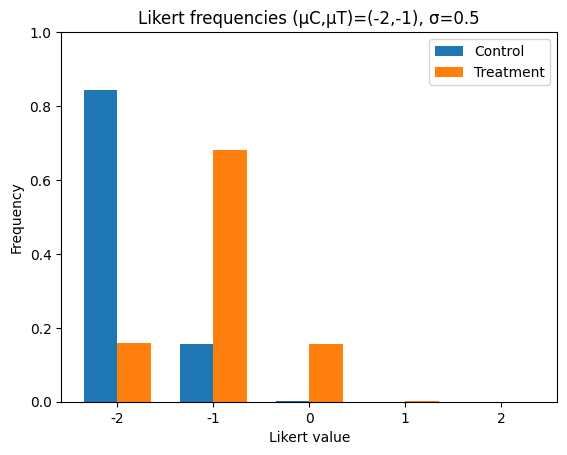

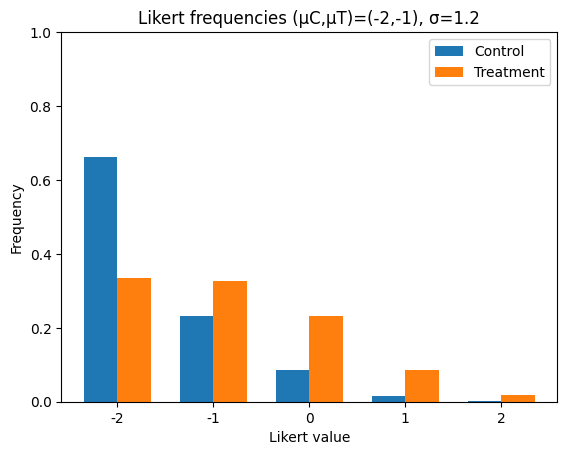

In [ ]:
# Parameters
mean_pairs = [(-1, 1), (1, 0), (1.5, 0.5), (-2, -1)]
sigmas = [0.5, 1.2]
K = 20000

LIKERT_LEVELS = np.array([-2, -1, 0, 1, 2])

def likert_freq(mu, sigma, K, seed=0):
    rng = np.random.default_rng(seed)
    vals = to_likert(rng.normal(mu, sigma, size=K))
    return np.array([(vals == lvl).mean() for lvl in LIKERT_LEVELS])

for (mu_c, mu_t) in mean_pairs:
    for sigma in sigmas:
        fC = likert_freq(mu_c, sigma, K=K, seed=10)
        fT = likert_freq(mu_t, sigma, K=K, seed=11)

        x = np.arange(len(LIKERT_LEVELS))
        w = 0.35

        plt.figure()
        plt.bar(x - w/2, fC, w, label="Control")
        plt.bar(x + w/2, fT, w, label="Treatment")
        plt.xticks(x, LIKERT_LEVELS)
        plt.ylim(0, 1)
        plt.title(f"Likert frequencies (μC,μT)=({mu_c},{mu_t}), σ={sigma}")
        plt.xlabel("Likert value")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()


2. d. we use the difference in mean Likert scores:

$$
\Delta=\bar{Y}_T-\bar{Y}_C
$$

because in **2.a** this statistic directly produces the two sampling distributions (centered near 0 under $H_0$, shifted under $H_1$). In **2.b**, changes in $\sigma$ and ceiling/floor effects change the average observed Likert score, so $\Delta$ captures the treatment shift well.

2. e.

* **Sample size n = 15 per group:** we should choose n larger when $\sigma$ is larger. In 2.b, $\sigma =1.2$ gives more overlap + ceiling/floor clipping, so it needs a bigger n than $\sigma =0.5$. I use n = 15 per group as a baseline.

* **Monte-Carlo repetitions (K):** the Monte-Carlo error of an estimated rejection probability shrinks like $1/\sqrt{K}$ with $K=20{,}000$ the estimate is stable enough to compare condition

3. we estimated the power of an independent two-sample Welch t-test and the Mann-Whitney U (MWU) test using Monte-Carlo empirical sampling. For each of the 8 conditions (4 mean tuples x 2 standard deviations), we generated K=20000 pseudo-experiments with n=15 participants per group by sampling from the specified normal populations, mapping the continuous values to the 5-point Likert scale (rounding to the nearest category and clipping to [-2,2]) and then running both tests at $\alpha=0.05$ (two-sided). Power was computed as the relative frequency of rejections ($p<\alpha$) across the K repetitions.

* With low variability ($\sigma=0.5$), power is essentially perfect for all tuples (≈0.99-1.00) because the Likert responses are tightly concentrated and the groups remain clearly separated. With higher variability ($\sigma=1.2$), power drops strongly for the 1-point mean differences (1,0), (1.5,0.5), and (-2,-1) (≈0.48-0.55) due to increased overlap and because discretization/clipping (floor/ceiling effects) reduces the effective observable separation on the bounded Likert scale. In contrast, (-1,1) retains very high power (≈0.985-0.987) even at $\sigma=1.2$ because the underlying mean difference is large (2 points). Across conditions, the Welch t-test is slightly more powerful than MWU in the harder $(high-\sigma)$ cases, which is consistent with MWU losing some sensitivity when many ties occur in a 5-level Likert scale.


In [ ]:
# PARAMETERS
ALPHA = 0.05
N_PER_GROUP = 15
K_MONTE_CARLO = 20000

MEAN_PAIRS = [
    (-1.0,  1.0),
    ( 1.0,  0.0),
    ( 1.5,  0.5),
    (-2.0, -1.0)
]

SIGMAS = [0.5, 1.2]

def run_one_experiment(mu_c, mu_t, sigma, n, rng):
    C = to_likert(rng.normal(mu_c, sigma, size=n))
    T = to_likert(rng.normal(mu_t, sigma, size=n))
    return C, T

def estimate_power(mu_c, mu_t, sigma, n, K, alpha, seed=0):
    rng = np.random.default_rng(seed)
    reject_t = 0
    reject_mw = 0

    for _ in range(K):
        C, T = run_one_experiment(mu_c, mu_t, sigma, n, rng)

        p_t = stats.ttest_ind(C, T, equal_var=False).pvalue
        p_mw = stats.mannwhitneyu(C, T, alternative="two-sided").pvalue

        reject_t += (p_t < alpha)
        reject_mw += (p_mw < alpha)

    return reject_t / K, reject_mw / K

rows = []
for (mu_c, mu_t) in MEAN_PAIRS:
    for sigma in SIGMAS:
        power_t, power_mw = estimate_power(
            mu_c=mu_c,
            mu_t=mu_t,
            sigma=sigma,
            n=N_PER_GROUP,
            K=K_MONTE_CARLO,
            alpha=ALPHA,
            seed=0
        )
        rows.append({
            "mu_C": mu_c,
            "mu_T": mu_t,
            "sigma": sigma,
            "power_t_test": power_t,
            "power_MWU": power_mw
        })

df_power = pd.DataFrame(rows)
print(df_power)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


   mu_C  mu_T  sigma  power_t_test  power_MWU
0  -1.0   1.0    0.5       1.00000    1.00000
1  -1.0   1.0    1.2       0.98695    0.98440
2   1.0   0.0    0.5       0.99565    0.99465
3   1.0   0.0    1.2       0.55350    0.53250
4   1.5   0.5    0.5       0.99480    0.99435
5   1.5   0.5    1.2       0.53330    0.51680
6  -2.0  -1.0    0.5       0.99095    0.98855
7  -2.0  -1.0    1.2       0.49220    0.48130


4. How could you model common biases (at least two) and how would they affect the outcome and power? Use your expected tuples of means and the standard deviations. Compute, interpret, and visualize. <br>
    _Hint: In the lectures 06 and 07 some common biases for these kinds of scales were discussed, but you can also choose other common [response biases](https://en.wikipedia.org/wiki/Response_bias) that you find interesting._

##### Bias 1: Central-tendency bias (avoid extremes)

**Behavior:** respondents avoid “strongly disagree/agree”, answering closer to neutral.

**Model (shrink toward 0 on the latent scale):**

x' = gamma * x ,   where 0 < gamma < 1

Effect:

* **Outcome distribution:** more mass at (-1,0,1), fewer ±2.
* **Observed effect (mean difference):**  
  Δ = mean(Treatment) - mean(Control), which typically shrinks (attenuation).
* **Power:** typically decreases, especially for harder cases (σ=1.2 and the 1-point mean differences), because the observable separation becomes smaller and ties increase.

##### Bias 2: Acquiescence / “yea-saying” (systematic agreement shift)
 **Behavior:** respondents systematically answer more positively (agreeing more often), a classic response bias (also related to “social desirability” patterns).

 **Model (add constant positive shift on the latent scale):**

x' = x + b ,   where b > 0


Effect (depends on where the means are relative to the ±2 bounds):
* **Outcome distribution:** shifts toward 1 and 2.
* **Ceiling interaction:** in already positive conditions (e.g. ((1.5,0.5))), more responses clip at +2, which can compress differences and reduce power.
 * In negative conditions (e.g. (-2,-1)), a positive shift can reduce floor saturation at -2, changing $\Delta$ and sometimes power. This is a concrete example of “cut-offs/boundaries creating artifacts” in discretized scales.


 Bias results
    mu_C  mu_T  sigma          bias      E[Δ]     SD(Δ)  power_t  power_MWU
0   -1.0   1.0    0.5          none  1.996813  0.206539  1.00000    1.00000
1   -1.0   1.0    0.5       central  1.453913  0.171624  0.99990    1.00000
2   -1.0   1.0    0.5  acquiescence  1.979827  0.205476  1.00000    1.00000
3   -1.0   1.0    1.2          none  1.752333  0.379595  0.98825    0.98685
4   -1.0   1.0    1.2       central  1.364107  0.311144  0.98505    0.98320
5   -1.0   1.0    1.2  acquiescence  1.696957  0.372073  0.98620    0.98545
6    1.0   0.0    0.5          none -0.998600  0.208147  0.99540    0.99465
7    1.0   0.0    0.5       central -0.726997  0.157937  0.98860    0.98615
8    1.0   0.0    0.5  acquiescence -0.975740  0.206244  0.99455    0.99455
9    1.0   0.0    1.2          none -0.878733  0.395278  0.55790    0.54675
10   1.0   0.0    1.2       central -0.682880  0.316068  0.53925    0.52650
11   1.0   0.0    1.2  acquiescence -0.793107  0.370660  0.53440    0.529

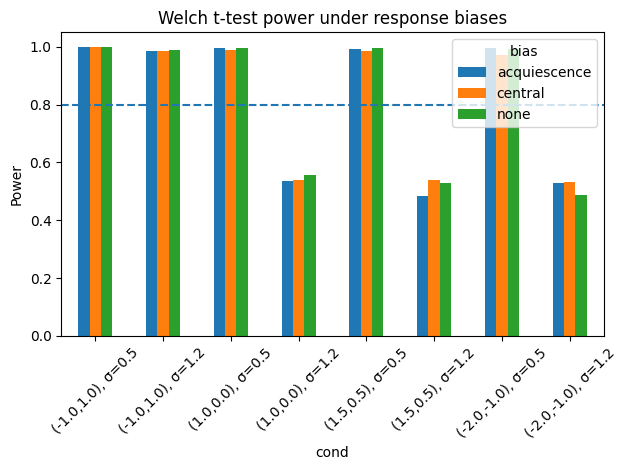

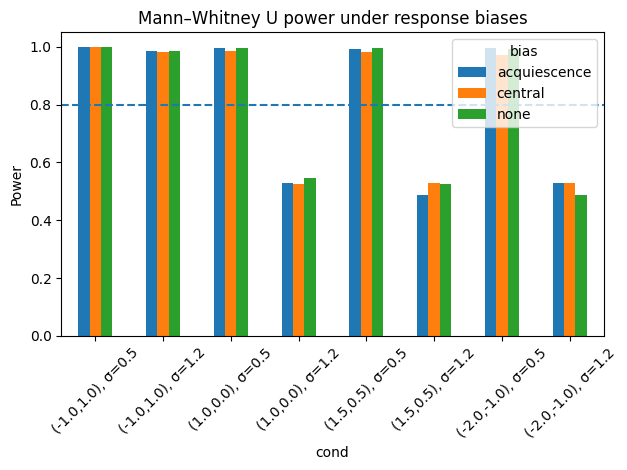

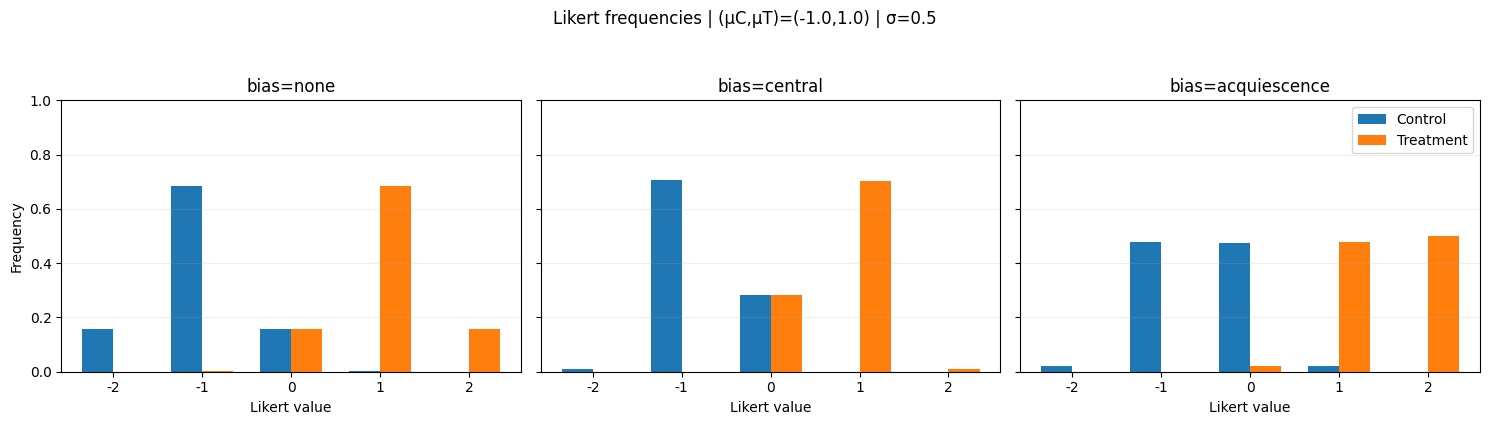

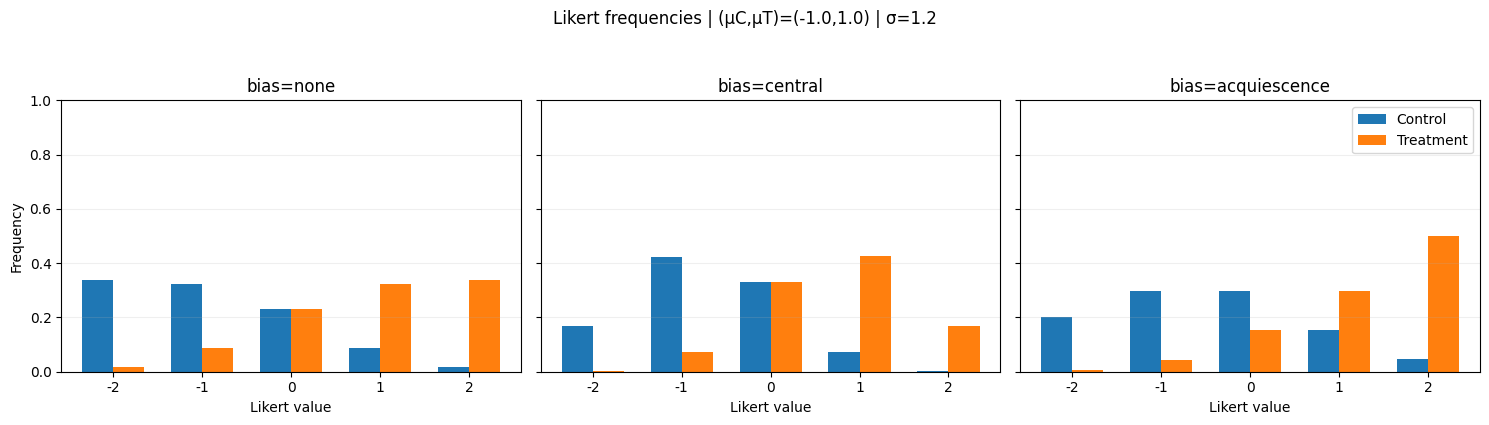

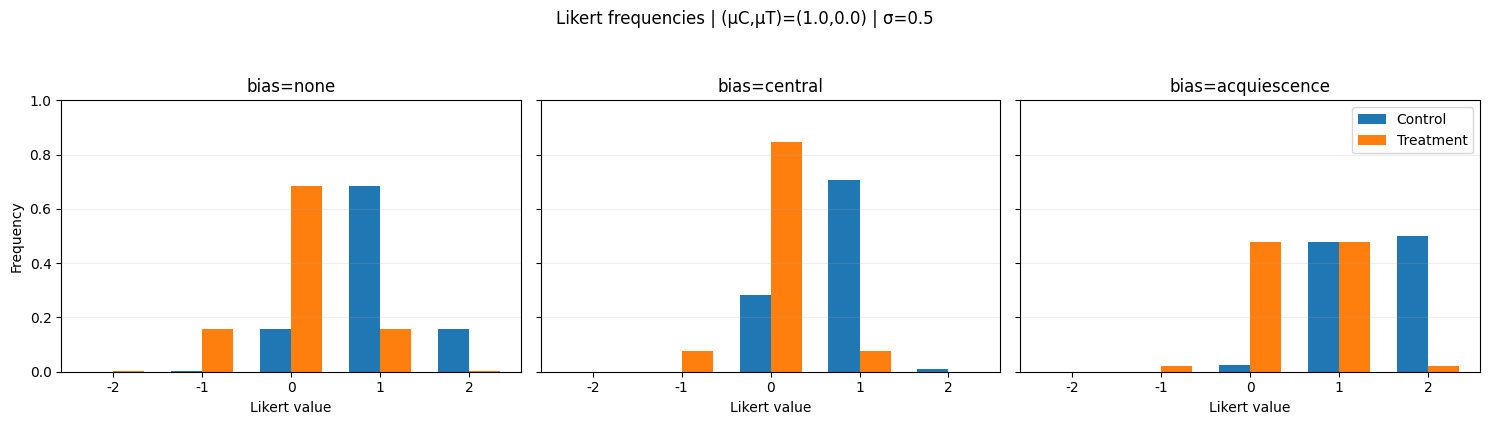

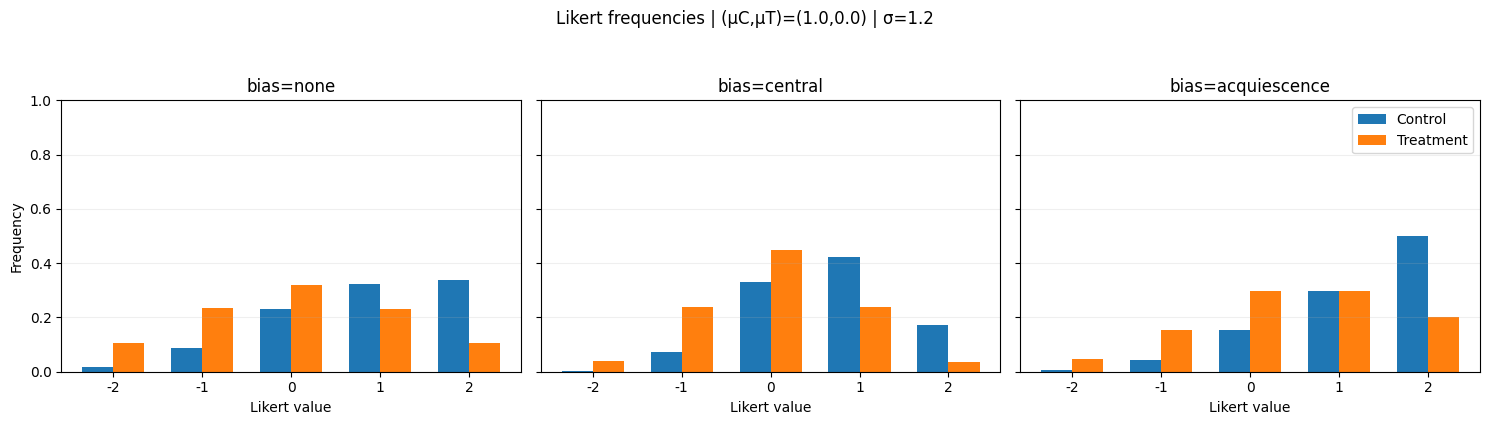

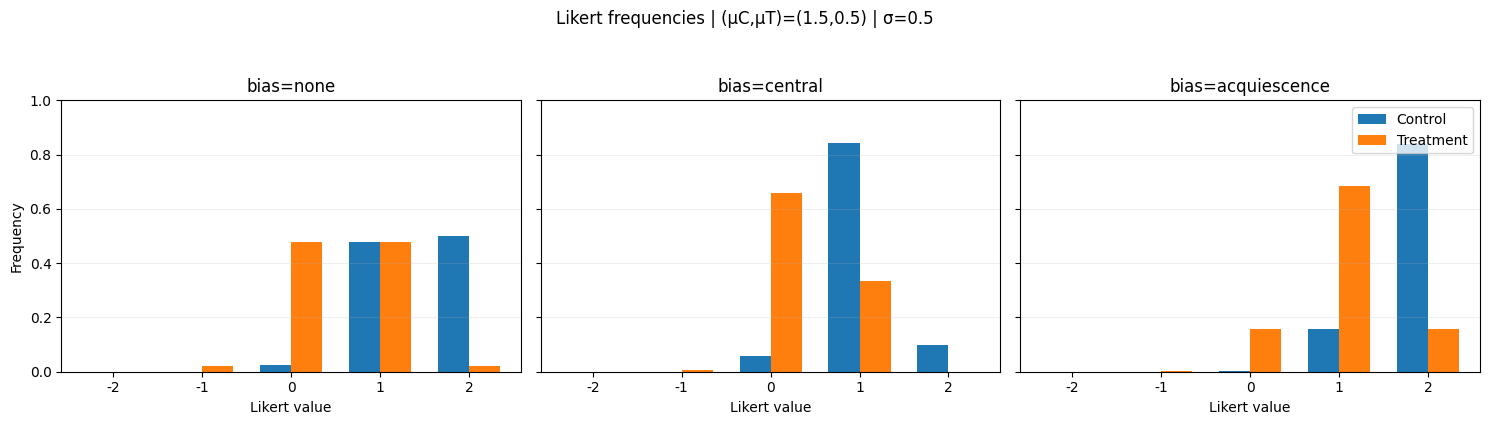

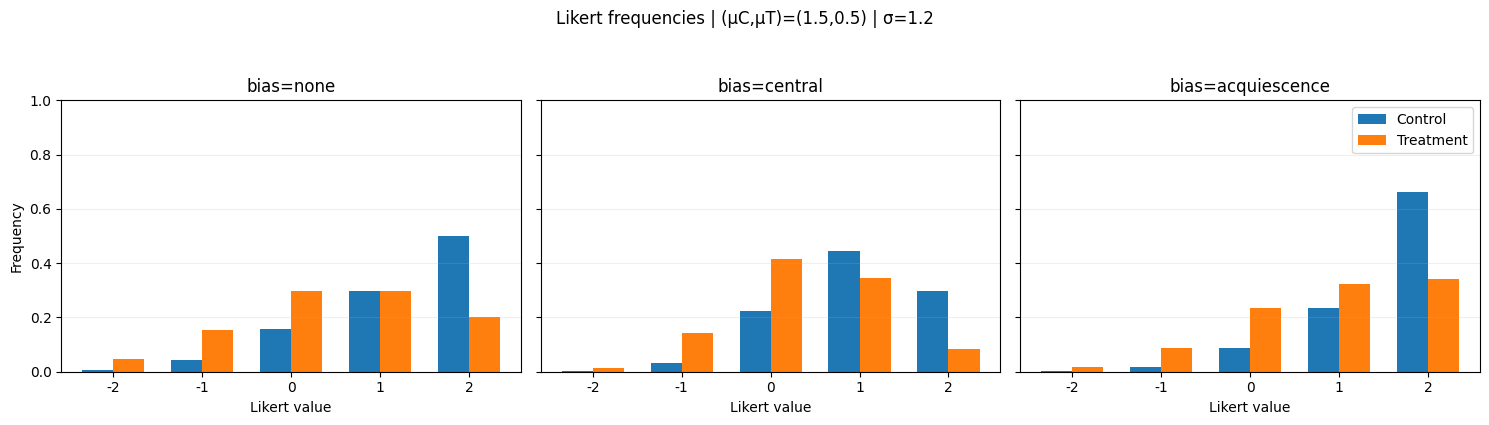

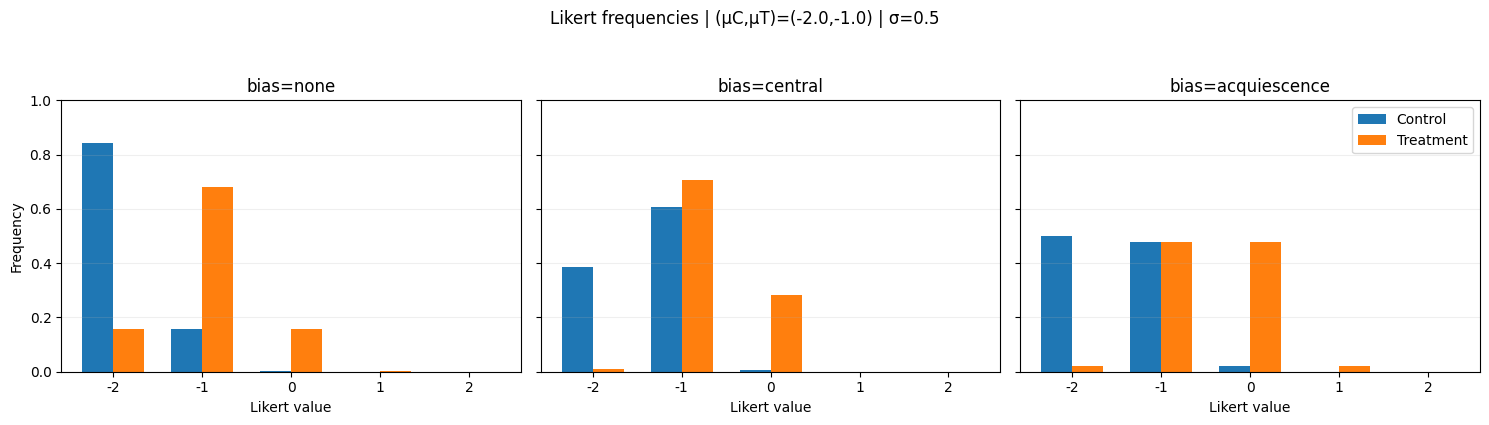

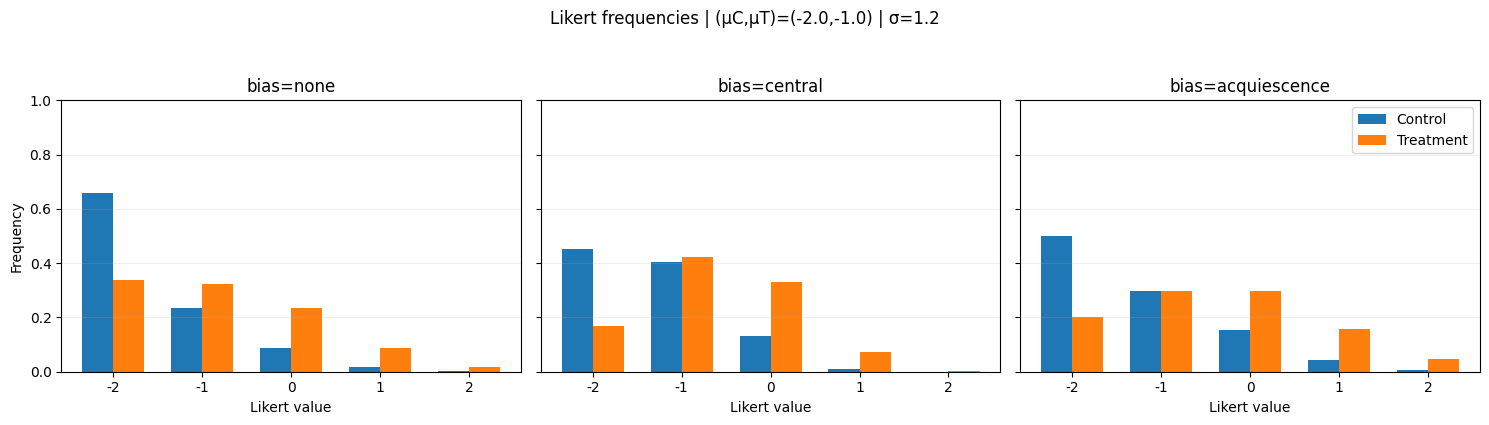

In [9]:
# Parameters
MEAN_PAIRS = [(-1.0,  1.0), (1.0, 0.0), (1.5, 0.5), (-2.0, -1.0)]
SIGMAS = [0.5, 1.2]                       # same as 2b
BIASES = ["none", "central", "acquiescence"]

ALPHA = 0.05
N = 15
K = 20000                                  # Monte-Carlo repetitions
SEED = 42

GAMMA = 0.7
B_SHIFT = 0.5

LIKERT_LEVELS = np.array([-2, -1, 0, 1, 2])

def to_likert(x: np.ndarray) -> np.ndarray:
    return np.clip(np.rint(x), -2, 2).astype(np.int8)

def apply_bias(x: np.ndarray, bias: str, gamma: float = GAMMA, b: float = B_SHIFT) -> np.ndarray:
    if bias == "none":
        return x
    if bias == "central":
        return gamma * x
    if bias == "acquiescence":
        return x + b
    raise ValueError(f"Unknown bias: {bias}")

def welch_t_pvals(C: np.ndarray, T: np.ndarray) -> np.ndarray:
    n1, n2 = C.shape[1], T.shape[1]
    m1, m2 = C.mean(axis=1), T.mean(axis=1)
    v1, v2 = C.var(axis=1, ddof=1), T.var(axis=1, ddof=1)
    se2 = v1/n1 + v2/n2

    bad = se2 <= 0  # no variability => no information
    tstat = np.zeros_like(se2, dtype=float)
    tstat[~bad] = (m2[~bad] - m1[~bad]) / np.sqrt(se2[~bad])

    num = se2**2
    den = (v1**2)/((n1**2)*(n1-1)) + (v2**2)/((n2**2)*(n2-1))

    good = (~bad) & (den > 0)
    df = np.zeros_like(se2, dtype=float)
    df[good] = num[good] / den[good]

    p = np.ones_like(se2, dtype=float)
    p[good] = 2 * tdist.sf(np.abs(tstat[good]), df[good])
    return p

def mwu_pvals_from_counts(C: np.ndarray, T: np.ndarray) -> np.ndarray:
    Kexp, n1 = C.shape
    n2 = T.shape[1]
    Ntot = n1 + n2

    c_counts = np.stack([(C == lvl).sum(axis=1) for lvl in LIKERT_LEVELS], axis=1)  # (Kexp, 5)
    t_counts = np.stack([(T == lvl).sum(axis=1) for lvl in LIKERT_LEVELS], axis=1)  # (Kexp, 5)

    cum_c_less = np.cumsum(c_counts, axis=1) - c_counts
    U = (t_counts * (cum_c_less + 0.5*c_counts)).sum(axis=1).astype(float)

    meanU = n1 * n2 / 2.0
    tie_sizes = c_counts + t_counts
    tie_term = (tie_sizes**3 - tie_sizes).sum(axis=1)

    varU = (n1*n2/12.0) * ((Ntot + 1) - tie_term/(Ntot*(Ntot - 1)))

    bad = varU <= 0
    z = np.zeros_like(varU, dtype=float)
    z[~bad] = (U[~bad] - meanU) / np.sqrt(varU[~bad])

    p = np.ones_like(varU, dtype=float)
    p[~bad] = 2 * norm.sf(np.abs(z[~bad]))
    return p

def simulate_condition(mu_c, mu_t, sigma, bias, n=N, Kexp=K, alpha=ALPHA, seed=SEED):
    rng = np.random.default_rng(seed)

    C_lat = rng.normal(mu_c, sigma, size=(Kexp, n))
    T_lat = rng.normal(mu_t, sigma, size=(Kexp, n))

    C_lat = apply_bias(C_lat, bias=bias)
    T_lat = apply_bias(T_lat, bias=bias)

    C = to_likert(C_lat).astype(np.int16)
    T = to_likert(T_lat).astype(np.int16)

    delta = T.mean(axis=1) - C.mean(axis=1)

    p_t  = welch_t_pvals(C, T)
    p_mw = mwu_pvals_from_counts(C, T)

    pool_C = C.ravel()
    pool_T = T.ravel()
    fC = np.array([(pool_C == lvl).mean() for lvl in LIKERT_LEVELS])
    fT = np.array([(pool_T == lvl).mean() for lvl in LIKERT_LEVELS])

    return {
        "E[Δ]": float(delta.mean()),
        "SD(Δ)": float(delta.std(ddof=1)),
        "power_t": float((p_t < alpha).mean()),
        "power_MWU": float((p_mw < alpha).mean()),
        "freq_C": fC,
        "freq_T": fT
    }

rows = []
freq_store = {}  # (mu_c, mu_t, sigma, bias) -> (freqC, freqT)

for (mu_c, mu_t) in MEAN_PAIRS:
    for sigma in SIGMAS:
        for bias in BIASES:
            cond_seed = SEED + (hash((mu_c, mu_t, sigma, bias)) % (2**16))
            res = simulate_condition(mu_c, mu_t, sigma, bias=bias, seed=cond_seed)

            rows.append({
                "mu_C": mu_c,
                "mu_T": mu_t,
                "sigma": sigma,
                "bias": bias,
                "E[Δ]": res["E[Δ]"],
                "SD(Δ)": res["SD(Δ)"],
                "power_t": res["power_t"],
                "power_MWU": res["power_MWU"]
            })

            freq_store[(mu_c, mu_t, sigma, bias)] = (res["freq_C"], res["freq_T"])

df_bias = pd.DataFrame(rows)
print("\n Bias results")
print(df_bias)

# Power plots
df_bias["cond"] = df_bias.apply(lambda r: f"({r.mu_C},{r.mu_T}), σ={r.sigma}", axis=1)
order = [f"({a},{b}), σ={s}" for (a, b) in MEAN_PAIRS for s in SIGMAS]

for col, title in [("power_t", "Welch t-test power"), ("power_MWU", "Mann–Whitney U power")]:
    pivot = df_bias.pivot(index="cond", columns="bias", values=col).loc[order]
    pivot.plot(kind="bar", rot=45)
    plt.axhline(0.8, linestyle="--")
    plt.ylabel("Power")
    plt.title(title + " under response biases")
    plt.tight_layout()
    plt.show()

# Likert frequency plots
x = np.arange(len(LIKERT_LEVELS))
w = 0.35

for (mu_c, mu_t) in MEAN_PAIRS:
    for sigma in SIGMAS:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

        for ax, bias in zip(axes, BIASES):
            fC, fT = freq_store[(mu_c, mu_t, sigma, bias)]

            ax.bar(x - w/2, fC, w, label="Control")
            ax.bar(x + w/2, fT, w, label="Treatment")
            ax.set_xticks(x)
            ax.set_xticklabels(LIKERT_LEVELS)
            ax.set_ylim(0, 1)
            ax.set_xlabel("Likert value")
            ax.set_title(f"bias={bias}")
            ax.grid(axis="y", alpha=0.2)

        axes[0].set_ylabel("Frequency")
        axes[-1].legend(loc="upper right")

        fig.suptitle(f"Likert frequencies | (μC,μT)=({mu_c},{mu_t}) | σ={sigma}", y=1.05)
        plt.tight_layout()
        plt.show()


##### Interpretation

* **Central-tendency bias** $(x'=\gamma x)$ consistently shrinks the observed effect $|E[\Delta]|$ because answers move toward (-1,0,1). Example: for $(\mu_C,\mu_T)=(-1,1)$, $\sigma=1.2$, $E[\Delta]$ drops from 1.75 to 1.36. This usually causes a small power decrease in the harder high-variance cases (e.g. (1,0), $\sigma=1.2$: t-test 0.555 to 0.544, MWU 0.543 to 0.530).

* **Acquiescence / yea-saying** $(x'=x+b)$ shifts responses upward and interacts with the +2 ceiling. In already-positive conditions, clipping compresses differences and reduces power, e.g. (1.5,0.5), $\sigma=1.2$: power drops from 0.532 to 0.488 (t-test) and 0.527 to 0.491 (MWU). In negative conditions, it can reduce floor effects and increase $E[\Delta]$ (e.g. (-2,-1), $\sigma=1.2$: 0.659 → 0.789).

* With low variance $(\sigma=0.5)$, power stays ~**1.0** for all biases; with high variance ($\sigma=1.2$), biases matter a lot. Overall, the **Welch t-test** is slightly more powerful than **MWU**, which is expected because a 5-point Likert scale creates many ties.


5. For the tuple of means of (1.5, 0.5), how large would the sample have to be in order to get a power of 80% for α=5%? Use the two different standard deviations as used in subtask 2b.

Minimum n per group for 80% power (alpha=0.05), (mu_C,mu_T)=(1.5,0.5)
   sigma  n_ttest  power_t_at_n  power_mw_at_n_t  n_mwu  power_t_at_n_mw  \
0    0.5        7       0.83565          0.82195      7          0.83835   
1    1.2       27       0.80060          0.79450     28          0.81645   

   power_mw_at_n  
0        0.82495  
1        0.81085  


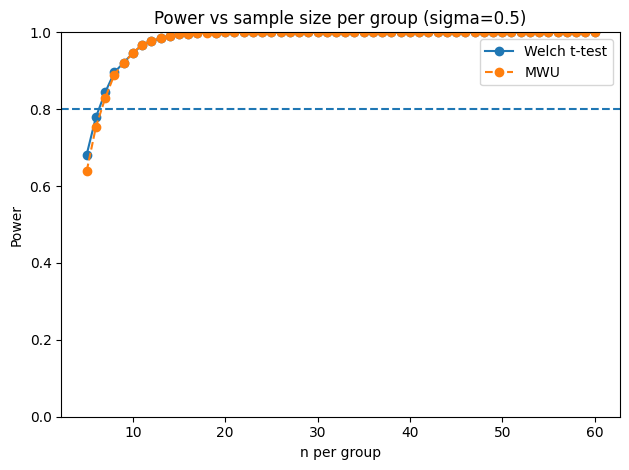

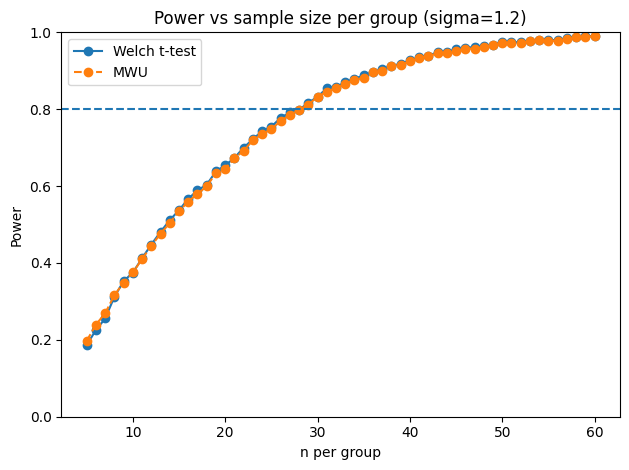

In [ ]:
MU_C, MU_T = 1.5, 0.5          #  tuple is (mu_C, mu_T)
SIGMAS = [0.5, 1.2]
ALPHA = 0.05
TARGET_POWER = 0.80

K_COARSE = 5000
K_FINE = 20000
SEED = 42

LIKERT_LEVELS = np.array([-2, -1, 0, 1, 2])

def to_likert(x: np.ndarray) -> np.ndarray:
    return np.clip(np.rint(x), -2, 2).astype(np.int8)

def welch_t_pvals(C: np.ndarray, T: np.ndarray) -> np.ndarray:
    n1, n2 = C.shape[1], T.shape[1]
    m1, m2 = C.mean(axis=1), T.mean(axis=1)
    v1, v2 = C.var(axis=1, ddof=1), T.var(axis=1, ddof=1)

    se2 = v1/n1 + v2/n2
    bad = se2 <= 0

    tstat = np.zeros_like(se2, dtype=float)
    tstat[~bad] = (m2[~bad] - m1[~bad]) / np.sqrt(se2[~bad])

    num = se2**2
    den = (v1**2)/((n1**2)*(n1-1)) + (v2**2)/((n2**2)*(n2-1))
    good = (~bad) & (den > 0)

    df = np.zeros_like(se2, dtype=float)
    df[good] = num[good] / den[good]

    p = np.ones_like(se2, dtype=float)
    p[good] = 2 * tdist.sf(np.abs(tstat[good]), df[good])
    return p


def mwu_pvals_from_counts(C: np.ndarray, T: np.ndarray) -> np.ndarray:
    Kexp, n1 = C.shape
    n2 = T.shape[1]
    N = n1 + n2

    c_counts = np.stack([(C == lvl).sum(axis=1) for lvl in LIKERT_LEVELS], axis=1).astype(np.int32)
    t_counts = np.stack([(T == lvl).sum(axis=1) for lvl in LIKERT_LEVELS], axis=1).astype(np.int32)

    cum_c_less = np.cumsum(c_counts, axis=1) - c_counts
    U = (t_counts * (cum_c_less + 0.5*c_counts)).sum(axis=1).astype(float)

    meanU = n1 * n2 / 2.0

    tie_sizes = c_counts + t_counts
    tie_term = (tie_sizes**3 - tie_sizes).sum(axis=1)
    varU = (n1*n2/12.0) * ((N + 1) - tie_term/(N*(N - 1)))

    bad = varU <= 0
    z = np.zeros_like(varU, dtype=float)
    z[~bad] = (U[~bad] - meanU) / np.sqrt(varU[~bad])

    p = np.ones_like(varU, dtype=float)
    p[~bad] = 2 * norm.sf(np.abs(z[~bad]))
    return p


def estimate_power(mu_c, mu_t, sigma, n, K, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    C_lat = rng.normal(mu_c, sigma, size=(K, n))
    T_lat = rng.normal(mu_t, sigma, size=(K, n))

    C = to_likert(C_lat).astype(np.int16)
    T = to_likert(T_lat).astype(np.int16)

    p_t  = welch_t_pvals(C, T)
    p_mw = mwu_pvals_from_counts(C, T)

    return float((p_t < alpha).mean()), float((p_mw < alpha).mean())


def find_min_n(mu_c, mu_t, sigma, target=0.80, alpha=0.05, seed=0):
    # coarse search in steps of 5
    candidate = None
    for n in range(5, 201, 5):
        pt, pm = estimate_power(mu_c, mu_t, sigma, n, K_COARSE, alpha, seed=seed)
        if pt >= target or pm >= target:
            candidate = n
            break

    if candidate is None:
        raise RuntimeError("Did not reach target power up to n=200")

    best_t = None
    best_mw = None
    for n in range(max(2, candidate-5), candidate+1):
        pt, pm = estimate_power(mu_c, mu_t, sigma, n, K_COARSE, alpha, seed=seed+1)
        if best_t is None and pt >= target:
            best_t = n
        if best_mw is None and pm >= target:
            best_mw = n
        if best_t is not None and best_mw is not None:
            break

    pt_t, pm_t = estimate_power(mu_c, mu_t, sigma, best_t,  K_FINE, alpha, seed=seed+2)
    pt_m, pm_m = estimate_power(mu_c, mu_t, sigma, best_mw, K_FINE, alpha, seed=seed+3)

    return {
        "sigma": sigma,
        "n_ttest": best_t,
        "power_t_at_n": pt_t,
        "power_mw_at_n_t": pm_t,
        "n_mwu": best_mw,
        "power_t_at_n_mw": pt_m,
        "power_mw_at_n": pm_m
    }

results = []
curve_rows = []

for sigma in SIGMAS:
    res = find_min_n(MU_C, MU_T, sigma, TARGET_POWER, ALPHA, SEED)
    results.append(res)

    # power curve for visualization
    for n in range(5, 61, 1):
        pt, pm = estimate_power(MU_C, MU_T, sigma, n, K_COARSE, ALPHA, seed=SEED)
        curve_rows.append({"sigma": sigma, "n": n, "power_t": pt, "power_mw": pm})

df_results = pd.DataFrame(results)
print("Minimum n per group for 80% power (alpha=0.05), (mu_C,mu_T)=(1.5,0.5)")
print(df_results)

df_curve = pd.DataFrame(curve_rows)

for sigma in SIGMAS:
    sub = df_curve[df_curve["sigma"] == sigma]
    plt.figure()
    plt.plot(sub["n"], sub["power_t"], marker="o", label="Welch t-test")
    plt.plot(sub["n"], sub["power_mw"], marker="o", linestyle="--", label="MWU")
    plt.axhline(TARGET_POWER, linestyle="--")
    plt.title(f"Power vs sample size per group (sigma={sigma})")
    plt.xlabel("n per group")
    plt.ylabel("Power")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()


* **σ = 0.5:** Power rises very quickly because responses cluster tightly around the means, so the two groups remain clearly separated after Likert rounding. Both tests reach ≥80% power at n = 7 per group (t-test ≈ 0.84, MWU ≈ 0.82), and then power approaches 1.

* **σ = 1.2:** Power increases slowly because higher variability creates strong overlap, and the 5-point Likert scale adds many ties/ceiling effects, reducing usable information. The Welch t-test reaches 80% at n = 27, while MWU needs n = 28.

* Overall, the t-test is slightly more powerful near the threshold, and higher σ requires much larger samples to achieve the same power.